[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shikh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Class distribution after balancing:
 sentiment
positive    22500
negative    22500
Name: count, dtype: int64

Logistic Regression Classification Report:

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99      8250
    positive       0.99      0.99      0.99      6750

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



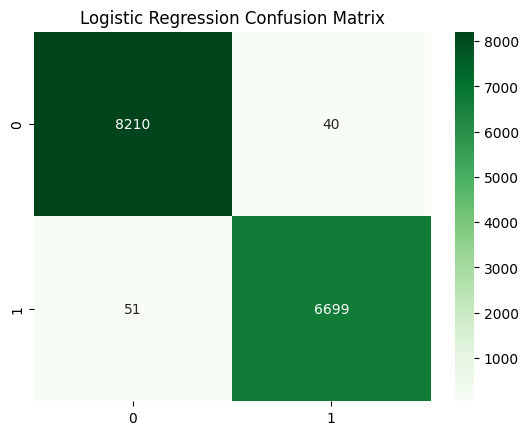


Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       0.99      1.00      1.00      8250
    positive       0.99      0.99      0.99      6750

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



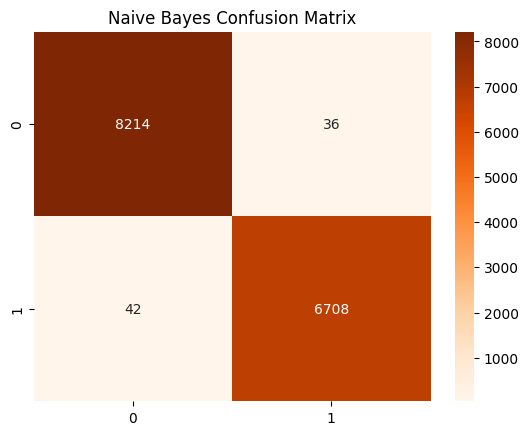


Models trained and Logistic Regression + Naive Bayes + Vectorizer saved!

Sample Predictions (Logistic Regression, threshold=0.55):
['positive', 'negative', 'negative', 'positive', 'negative']

Sample Predictions (Naive Bayes):
['positive', 'negative', 'negative', 'negative', 'negative']


In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import nltk
import re
import string
from wordcloud import WordCloud
import pickle
from sklearn.utils import resample

nltk.download('stopwords')

# Step 2: Load Dataset
data = pd.read_csv("reviews.csv")

# Step 3: Text Cleaning (preserve negations)
def clean_text(text):
    text = str(text)
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    text = text.lower()
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"'", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(text.split())
    return text



data['clean_text'] = data['Text'].apply(clean_text)
data['sentiment'] = data['Score'].apply(lambda x: 'positive' if x >= 4 else 'negative')

# Step 4: Balance dataset
positive = data[data['sentiment'] == 'positive']
negative = data[data['sentiment'] == 'negative']

negative_upsampled = resample(
    negative,
    replace=True,
    n_samples=len(positive),
    random_state=42
)

balanced_data = pd.concat([positive, negative_upsampled])
print("Class distribution after balancing:\n", balanced_data['sentiment'].value_counts())

# Step 5: Train-Test Split
X = data['clean_text']; y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42, stratify=y)


# Step 6: TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),stop_words='english', min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)


# Step 7: Logistic Regression with class weights
lr_model = LogisticRegression(class_weight='balanced', max_iter=300)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Step 8: Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

print("\nNaive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap="Oranges")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# Step 9: Custom prediction function with threshold
def custom_predict(model, vectorizer, texts, threshold=0.55, positive_label='positive'):
    vec = vectorizer.transform([clean_text(t) for t in texts])
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(vec)
        pos_idx = list(model.classes_).index(positive_label)
        return ["positive" if p[pos_idx] >= threshold else "negative" for p in probs]
    else:
        return model.predict(vec)



# Step 10: Save Logistic Regression + Naive Bayes models + vectorizer
with open("models/sentiment_lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("models/sentiment_nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

with open("models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("\nModels trained and Logistic Regression + Naive Bayes + Vectorizer saved!")

# Step 11: Sample Predictions
sample_reviews = [
    "I love this product, it’s amazing and works great!",
    "Worst experience ever, totally waste of money.",
    "It’s decent, not too good not too bad.",
    "The product is not good at all, very disappointing.",
    "I don’t like this product, it’s awful."
]

print("\nSample Predictions (Logistic Regression, threshold=0.55):")
print(custom_predict(lr_model, tfidf, sample_reviews, threshold=0.55))

print("\nSample Predictions (Naive Bayes):")
print(custom_predict(nb_model, tfidf, sample_reviews, threshold=0.55))
